数据形状: (3114, 17)
日期范围: 2013-07-02 00:00:00 到 2026-04-22 00:00:00
特征数量: 13
训练集: (3014, 13), 测试集: (100, 13)

开始测试不同参数组合...
参数1: n_estimators=100, max_depth=3, learning_rate=0.1 → RMSE=1.1829, R²=0.8075
参数2: n_estimators=100, max_depth=5, learning_rate=0.1 → RMSE=1.0591, R²=0.8456
参数3: n_estimators=100, max_depth=7, learning_rate=0.1 → RMSE=1.2064, R²=0.7997
参数4: n_estimators=200, max_depth=3, learning_rate=0.1 → RMSE=1.3175, R²=0.7611
参数5: n_estimators=200, max_depth=5, learning_rate=0.1 → RMSE=1.3692, R²=0.7420
参数6: n_estimators=200, max_depth=7, learning_rate=0.1 → RMSE=1.3502, R²=0.7491
参数7: n_estimators=100, max_depth=5, learning_rate=0.05 → RMSE=1.0297, R²=0.8541
参数8: n_estimators=200, max_depth=5, learning_rate=0.05 → RMSE=1.0389, R²=0.8515
参数9: n_estimators=100, max_depth=3, learning_rate=0.05 → RMSE=1.0990, R²=0.8338
参数10: n_estimators=300, max_depth=5, learning_rate=0.05 → RMSE=1.0520, R²=0.8477

最优参数: n_estimators=100, max_depth=5, learning_rate=0.05

=== 测试集评估结果 ===
RMSE: 1.02

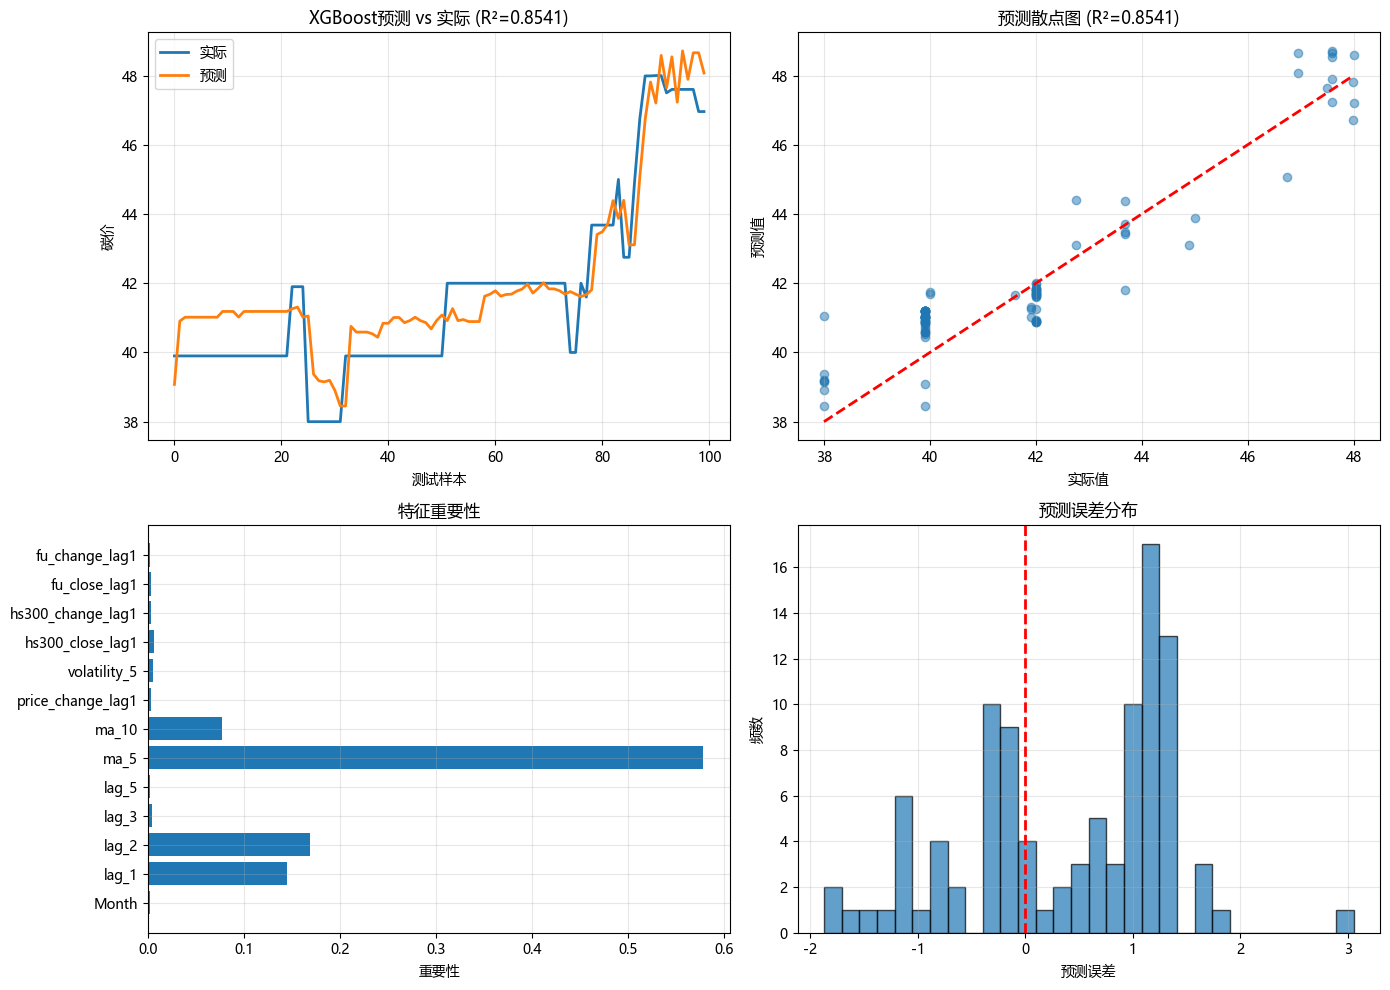


预测结果已保存至: test_predictions_xgboost.csv


In [15]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import xgboost as xgb

SEED = 42
TEST_SIZE = 100

np.random.seed(SEED)

# ==================== 读取数据 ====================
df = pd.read_csv("shenzhen.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date", ascending=True).reset_index(drop=True)

for col in ["close"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==================== 时间特征 ====================
df["Month"] = df["date"].dt.month

# ==================== 滞后特征（只用历史值） ====================
df["lag_1"] = df["close"].shift(1)
df["lag_2"] = df["close"].shift(2)
df["lag_3"] = df["close"].shift(3)
df["lag_5"] = df["close"].shift(5)

# ==================== 移动平均（修正：基于前一天的值） ====================
df["ma_5"] = df["close"].shift(1).rolling(window=5).mean()
df["ma_10"] = df["close"].shift(1).rolling(window=10).mean()

# ==================== 价格变化率（修正：昨天的变化率） ====================
df["price_change_lag1"] = df["close"].pct_change().shift(1)

# ==================== 波动率（修正：基于历史值） ====================
df["volatility_5"] = df["close"].shift(1).rolling(window=5).std()

# ==================== 沪深300（修正：只用历史值） ====================
hs300_path = "hs300_cache.csv"
if os.path.exists(hs300_path):
    hs300 = pd.read_csv(hs300_path)
    hs300["date"] = pd.to_datetime(hs300["date"])
    df = df.merge(hs300, on="date", how="left")
else:
    df["hs300_close"] = np.nan

df["hs300_close"] = df["hs300_close"].ffill().bfill()
if df["hs300_close"].isna().all():
    df["hs300_close"] = df["close"]

df["hs300_close_lag1"] = df["hs300_close"].shift(1)
df["hs300_change_lag1"] = df["hs300_close"].pct_change().shift(1)

# ==================== 燃料油（修正：只用历史值） ====================
fu_path = "fu0_cache.csv"
if os.path.exists(fu_path):
    fu_hist = pd.read_csv(fu_path)
    fu_hist["date"] = pd.to_datetime(fu_hist["date"])
    df = df.merge(fu_hist, on="date", how="left")
else:
    df["fu_close"] = np.nan

df["fu_close"] = df["fu_close"].ffill().bfill()
if df["fu_close"].isna().all():
    df["fu_close"] = df["close"]

df["fu_close_lag1"] = df["fu_close"].shift(1)
df["fu_change_lag1"] = df["fu_close"].pct_change().shift(1)

# ==================== 删除缺失值 ====================
df = df.dropna().reset_index(drop=True)

print(f"数据形状: {df.shape}")
print(f"日期范围: {df['date'].min()} 到 {df['date'].max()}")

# ==================== 特征列（全部使用历史值） ====================
feature_cols = [
    "Month",
    "lag_1", "lag_2", "lag_3", "lag_5",
    "ma_5", "ma_10",
    "price_change_lag1",
    "volatility_5",
    "hs300_close_lag1",
    "hs300_change_lag1",
    "fu_close_lag1",
    "fu_change_lag1"
]
target_col = "close"

X = df[feature_cols].values
y = df[target_col].values

print(f"特征数量: {len(feature_cols)}")

# ==================== 时间顺序划分 ====================
if len(X) <= TEST_SIZE:
    raise ValueError(f"样本不足，总样本数={len(X)}，无法划分最后{TEST_SIZE}个样本做测试")

X_train, X_test = X[:-TEST_SIZE], X[-TEST_SIZE:]
y_train, y_test = y[:-TEST_SIZE], y[-TEST_SIZE:]

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# ==================== 训练多个参数组合 ====================
param_sets = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 100, "max_depth": 7, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 7, "learning_rate": 0.1},
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05},
]

best_rmse = np.inf
best_params = None
best_model = None

print("\n开始测试不同参数组合...")
for i, params in enumerate(param_sets):
    model = xgb.XGBRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"参数{i+1}: n_estimators={params['n_estimators']}, max_depth={params['max_depth']}, "
          f"learning_rate={params['learning_rate']} → RMSE={rmse:.4f}, R²={r2:.4f}")
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params
        best_model = model

print(f"\n最优参数: n_estimators={best_params['n_estimators']}, "
      f"max_depth={best_params['max_depth']}, learning_rate={best_params['learning_rate']}")

# ==================== 最终预测 ====================
y_pred = best_model.predict(X_test)

y_true_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()
errors = y_pred_flat - y_true_flat

# ==================== 评估指标 ====================
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
mae = mean_absolute_error(y_true_flat, y_pred_flat)
mape = mean_absolute_percentage_error(y_true_flat, y_pred_flat) * 100
r2 = r2_score(y_true_flat, y_pred_flat)

print("\n=== 测试集评估结果 ===")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"MAPE: {mape:.4f}%")
print(f"R²: {r2:.6f}")

# ==================== 特征重要性 ====================
feature_importance = best_model.feature_importances_
print("\n=== 特征重要性 ===")
for name, imp in zip(feature_cols, feature_importance):
    print(f"{name}: {imp:.4f}")

# ==================== 可视化 ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(y_true_flat, label="实际", linewidth=2)
axes[0, 0].plot(y_pred_flat, label="预测", linewidth=2)
axes[0, 0].set_title(f"XGBoost预测 vs 实际 (R²={r2:.4f})")
axes[0, 0].set_xlabel("测试样本")
axes[0, 0].set_ylabel("碳价")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].scatter(y_true_flat, y_pred_flat, alpha=0.5)
axes[0, 1].plot([y_true_flat.min(), y_true_flat.max()], 
                [y_true_flat.min(), y_true_flat.max()], 'r--', linewidth=2)
axes[0, 1].set_title(f"预测散点图 (R²={r2:.4f})")
axes[0, 1].set_xlabel("实际值")
axes[0, 1].set_ylabel("预测值")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].barh(feature_cols, feature_importance)
axes[1, 0].set_title("特征重要性")
axes[1, 0].set_xlabel("重要性")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_title("预测误差分布")
axes[1, 1].set_xlabel("预测误差")
axes[1, 1].set_ylabel("频数")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 保存结果 ====================
save_path = "test_predictions_xgboost.csv"
result_df = pd.DataFrame({
    "actual_close": y_true_flat,
    "predicted_close": y_pred_flat,
    "error": errors,
    "abs_error": np.abs(errors)
})

result_df.to_csv(save_path, index=False)
print(f"\n预测结果已保存至: {save_path}")